In [1]:
import os

In [3]:
os.getcwd()

'/home/jingqi/RNALocateV3.0/Codes/Interpretation'

In [4]:
os.chdir('/home/jingqi/RNALocateV3.0/Data/Raw')

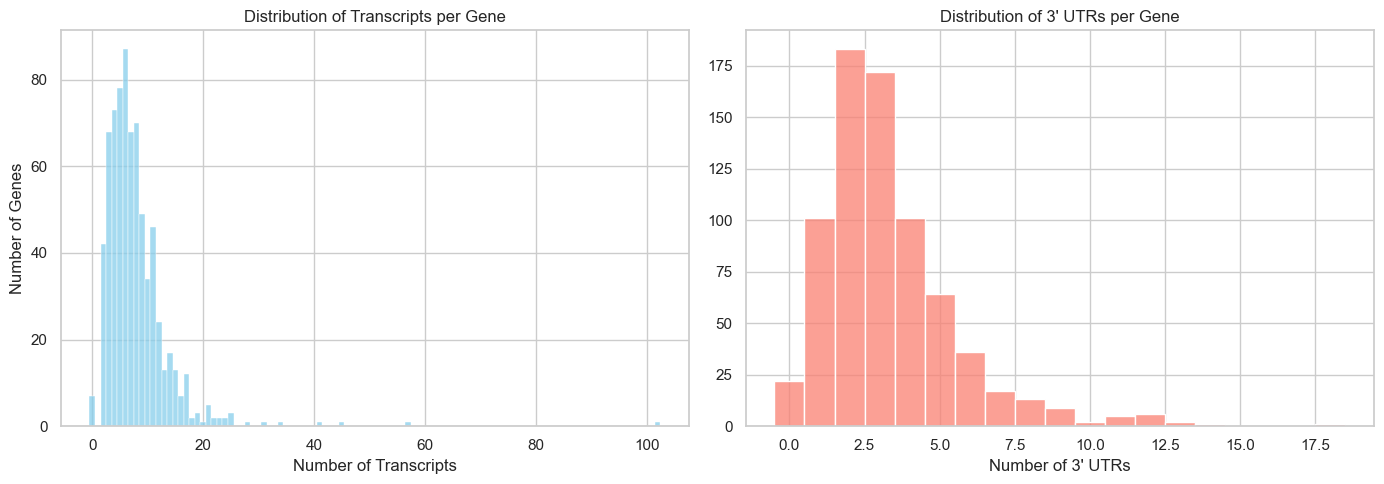

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

with open('gene_list.txt', 'r') as f:
    target_genes = set(line.strip() for line in f if line.strip())

def count_transcripts_with_zeros(file_path, gene_name_index):
    gene_counts = {gene: 0 for gene in target_genes}
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('>'):
                parts = line.strip()[1:].split('|')
                if len(parts) > gene_name_index:
                    gene_name = parts[gene_name_index]
                    if gene_name in gene_counts:
                        gene_counts[gene_name] += 1
    return gene_counts

full_transcript_counts = count_transcripts_with_zeros('FASTA_full.txt', 1)
utr_transcript_counts = count_transcripts_with_zeros('3UTR_clean.txt', 0)

full_values = list(full_transcript_counts.values())
utr_values = list(utr_transcript_counts.values())

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

sns.histplot(full_values, bins=range(0, max(full_values) + 2), 
             color="skyblue", ax=axes[0], discrete=True)
axes[0].set_title("Distribution of Transcripts per Gene")
axes[0].set_xlabel("Number of Transcripts")
axes[0].set_ylabel("Number of Genes")

sns.histplot(utr_values, bins=range(0, max(utr_values) + 2), 
             color="salmon", ax=axes[1], discrete=True)
axes[1].set_title("Distribution of 3' UTRs per Gene")
axes[1].set_xlabel("Number of 3' UTRs")
axes[1].set_ylabel("") 

plt.tight_layout()
plt.show()